Mounted at /content/drive

PC1 explains: 73.2% of variance
PC2 explains: 11.4% of variance
Total variance captured by 2 components: 84.6%

PC1 top contributors:
  Total_Daily_Load_max: 0.315
  Average_Load_max: 0.315
  Peak_Demand_mean: 0.311

PC2 top contributors:
  High_Load_Count_mean: 0.480
  Load_Variance_max: -0.452
  Peak_Demand_max: -0.363


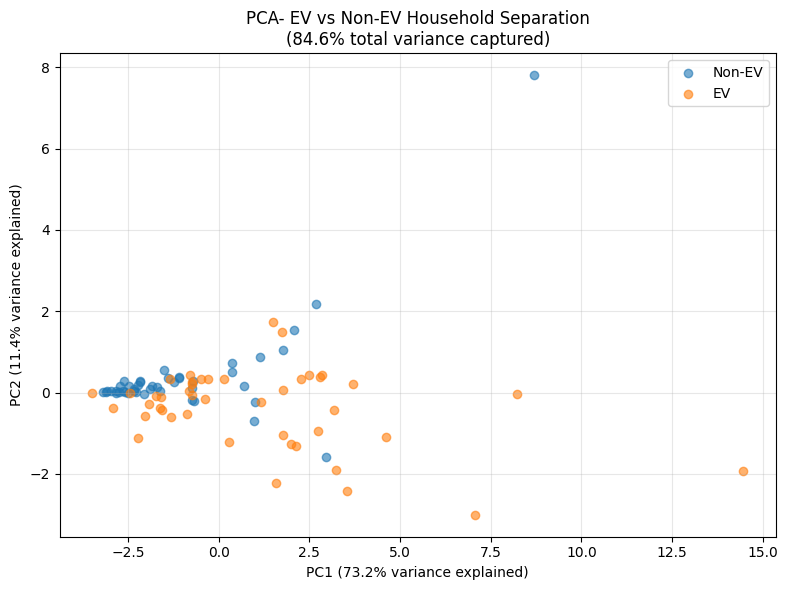


-----------------------------------------------
Overall Household Classification

Overall Household Classification Logistic Regression Training Accuracy: 81.82%
Overall Household Classification Logistic Regression Test Accuracy: 86.36%

Overall Household Classification K-NN Training Accuracy: 77.27%
Overall Household Classification K-NN Test Accuracy: 90.91%

-----------------------------------------------
Weekday Household Classification

Weekday Household Classification Logistic Regression Training Accuracy: 84.85%
Weekday Household Classification Logistic Regression Test Accuracy: 95.45%

Weekday Household Classification K-NN Training Accuracy: 83.33%
Weekday Household Classification K-NN Test Accuracy: 90.91%

-----------------------------------------------
Weekend Household Classification

Weekend Household Classification Logistic Regression Training Accuracy: 78.79%
Weekend Household Classification Logistic Regression Test Accuracy: 90.91%

Weekend Household Classification K-NN 

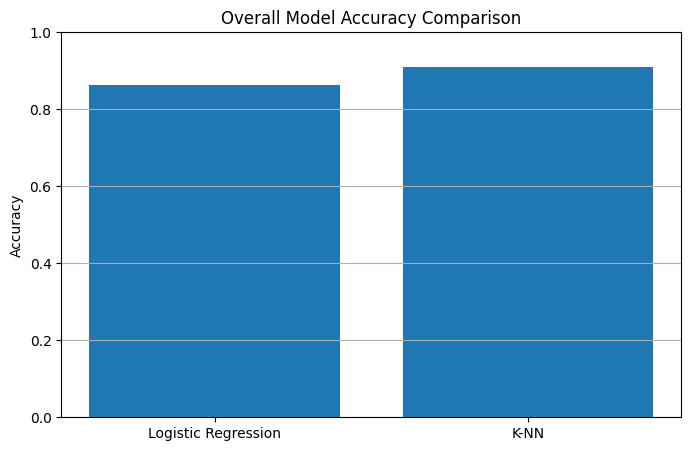


Weekday vs Weekend Accuracy Comparison:
  Logistic Regression - Weekday: 95.45%
  Logistic Regression - Weekend: 90.91%
  K-NN - Weekday: 90.91%
  K-NN - Weekend: 81.82%


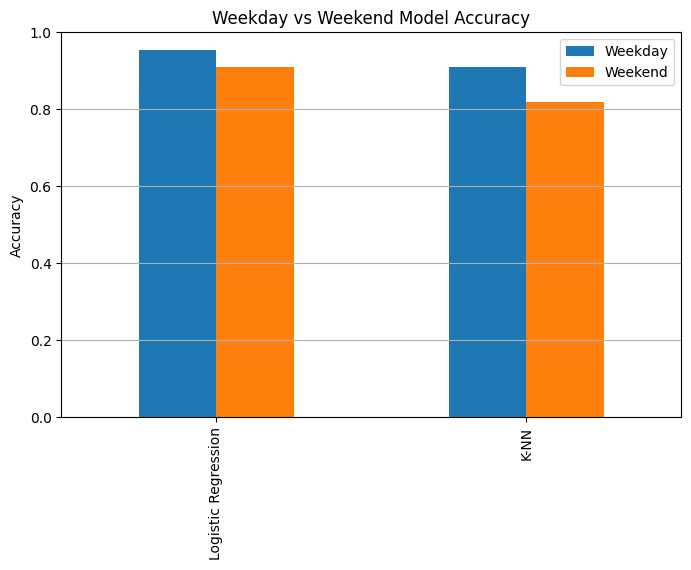


---TEMPORAL ANALYSIS CONCLUSION---
Weekday accuracy is higher, suggesting EV charging is MORE predictable
on weekdays- possibly due to consistent work-driven charging routines.


---CONFUSION MATRICES---///

Overall Classification (Logistic Regression):
[[ 9  2]
 [ 1 10]]


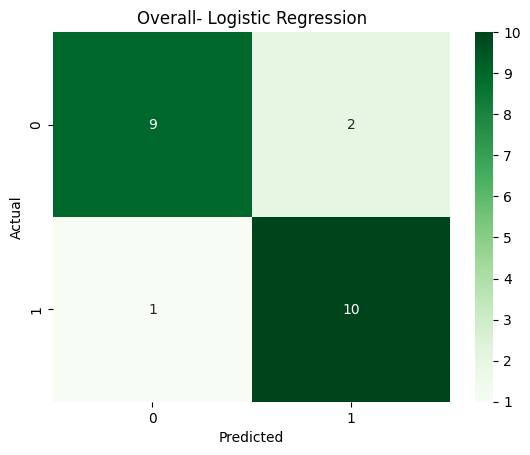


Overall Classification (K-NN):
[[10  1]
 [ 1 10]]


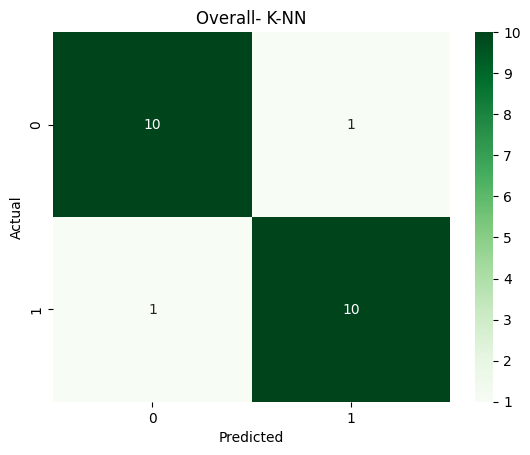


Weekday Classification (Logistic Regression):
[[11  0]
 [ 1 10]]


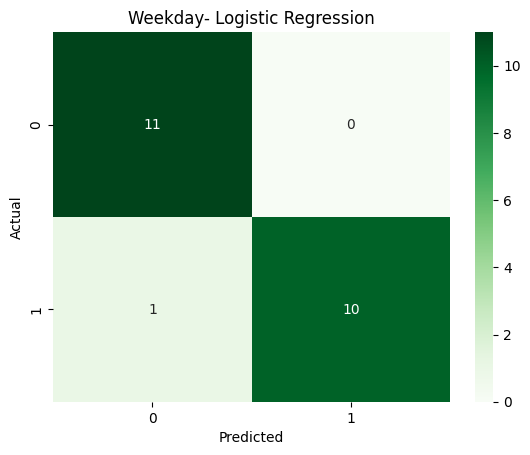


Weekday Classification (K-NN):
[[10  1]
 [ 1 10]]


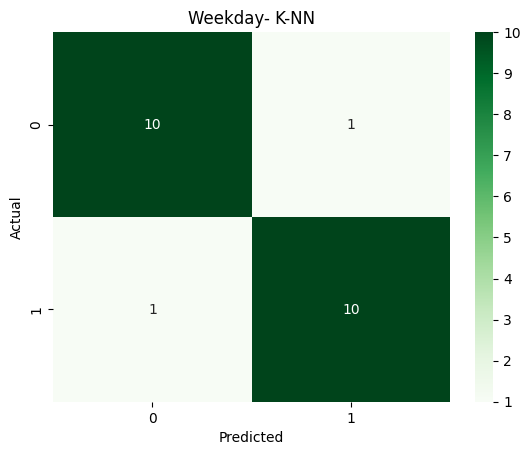


Weekend Classification (Logistic Regression):
[[ 9  2]
 [ 0 11]]


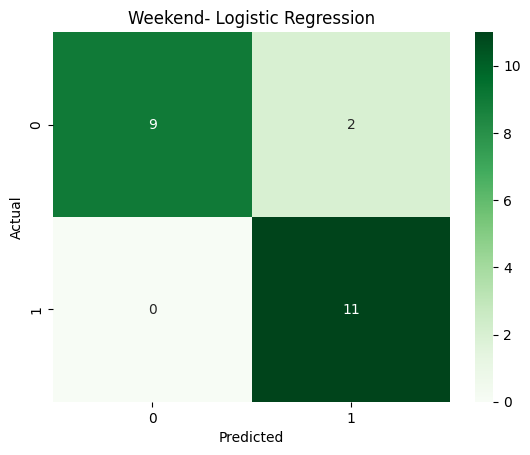


Weekend Classification (K-NN):
[[9 2]
 [2 9]]


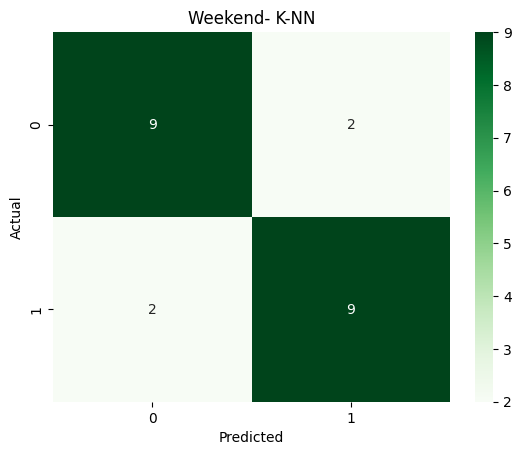


--- Overall- Logistic Regression ---
True Positives  (EV correctly identified):          10
False Positives (Non-EV wrongly labelled as EV):    2
False Negatives (EV missed by model):               1
True Negatives  (Non-EV correctly identified):      9
Sensitivity (EV detection rate):                    90.91%
Specificity (Non-EV rejection rate):                81.82%

--- Overall- K-NN ---
True Positives  (EV correctly identified):          10
False Positives (Non-EV wrongly labelled as EV):    1
False Negatives (EV missed by model):               1
True Negatives  (Non-EV correctly identified):      10
Sensitivity (EV detection rate):                    90.91%
Specificity (Non-EV rejection rate):                90.91%

--- Weekday- Logistic Regression ---
True Positives  (EV correctly identified):          10
False Positives (Non-EV wrongly labelled as EV):    0
False Negatives (EV missed by model):               1
True Negatives  (Non-EV correctly identified):      11
Sensitivity 

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Loading in the dataset from the google drive:
path = '/content/drive/MyDrive/Colab Notebooks/Project 7 - Dataset.csv'
df = pd.read_csv(path)

# This part converts read_date into datetime format so that we can extract the days of week
#Which allows us to split weekdays and weekends as per requirement
df['read_date'] = pd.to_datetime(df['read_date'], format='mixed')
df['day_index'] = df['read_date'].dt.dayofweek

#Weekdays (0-4) and weekends (5-6)
weekdays_df = df[df['day_index'] < 5]
weekends_df = df[df['day_index'] >= 5]

#Dthe 48 half-hour intervals covering the full day
interval_cols = [f'interval_{i}' for i in range(1, 49)]

#Night window: 11:00 PM to 5:00 AM (which are typical EV charging hours)
#At night large load is more likely to be EV charging
#Each interval is 30 minutes starting from interval_1=12:00 AM
#interval_47=11:00 PM and 48 is 11:30 PM
#interval_1-10 = 12:00 AM to 5:00 AM
night_cols = ['interval_47', 'interval_48'] + [f'interval_{i}' for i in range(1, 11)]

#This part is the feature engineering as it is creating the key features that will be used for classification
def add_features(data):
    data = data.copy()
    data['Peak_Demand'] = data[interval_cols].max(axis=1) #highest usage in one interval
    data['Night_Load'] = data[night_cols].sum(axis=1) #total overnight consumption(EV signature)
    data['Load_Variance'] = data[interval_cols].var(axis=1) #"spikiness" of the data- EVs create large and longer humps, and dryers are short spikes
    data['Total_Daily_Load'] = data[interval_cols].sum(axis=1)#total energy used in a day
    data['Average_Load'] = data[interval_cols].mean(axis=1)#average half-hour consumption
    data['High_Load_Count'] = (data[interval_cols] > 1.5).sum(axis=1)  #intervals exceeding 1.5kWh (EV draws 1.8-3.5kWh per interval)
    data['EV_Label'] = data['label']  # 1 = EV owner and 0 = Non-EV
    return data

df = add_features(df)
weekdays_df = add_features(weekdays_df)
weekends_df = add_features(weekends_df)

feature_cols = [
    'Peak_Demand',
    'Night_Load',
    'Load_Variance',
    'Total_Daily_Load',
    'Average_Load',
    'High_Load_Count'
]

#Aggregate by household
### takes mean and max across all days per user.
#Using max ensures that even if an EV owner only charges 2 times per week,the high-load charging days
## still influence the classification of the user
#EVs might not charge every day
def aggregate_by_user(data):
    agg_dict = {col: ['mean', 'max'] for col in feature_cols} #calculating mean and max for every feature column, done because EVs may only charge on some days
    agg_dict['EV_Label'] = 'max' # If a household is EV, max stays 1
    user_data = data.groupby('id').agg(agg_dict)  # group all rows belonging to the same household by their id
    new_columns = []
    for col in user_data.columns:
        if type(col) == tuple: #Checks if the column name is a tuple, since most columns after aggregation become tuples
            new_columns.append(col[0] + "_" + col[1])
        else:
            new_columns.append(col)
    user_data.columns = new_columns
    user_data = user_data.reset_index()
    return user_data

overall_user_df = aggregate_by_user(df)
weekday_user_df = aggregate_by_user(weekdays_df)
weekend_user_df = aggregate_by_user(weekends_df)

#PCA visualisation used only to show how well EV and Non-EV households separate in 2D space
##Models are trained on the full feature set not on the PCA
##PCA is only used to see if EV and Non-EV households separate clearly
def plot_pca_separation(user_data):
    X = user_data.drop(columns=['id', 'EV_Label_max'])
    y = user_data['EV_Label_max']
#Separate input features and output labels

    # Scale first-PCA is variance-based so unscaled features with large
    # magnitudes would unfairly dominate the principal components
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    #PCA on all data:
    pca = PCA(n_components=2) # Reduce features into 2 principal components
    X_pca = pca.fit_transform(X_scaled) # Fit scaler and transform data

    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]
    total_var = pc1_var + pc2_var # Total variance captured by both components

    print(f"\nPC1 explains: {pc1_var:.1%} of variance")
    print(f"PC2 explains: {pc2_var:.1%} of variance")
    print(f"Total variance captured by 2 components: {total_var:.1%}")

    #Shows which original features contribute most to each component
    print("\nPC1 top contributors:")
    for feature, weight in sorted(
        zip(X.columns, pca.components_[0]),
        key=lambda x: abs(x[1]), reverse=True
    )[:3]:
        print(f"  {feature}: {weight:.3f}")

    print("\nPC2 top contributors:")
    for feature, weight in sorted(
        zip(X.columns, pca.components_[1]),
        key=lambda x: abs(x[1]), reverse=True
    )[:3]:
        print(f"  {feature}: {weight:.3f}")

    #PCA scatterplot
    ev_mask = y == 1
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[~ev_mask, 0], X_pca[~ev_mask, 1], label='Non-EV', alpha=0.6)
    plt.scatter(X_pca[ev_mask, 0], X_pca[ev_mask, 1], label='EV', alpha=0.6)
    plt.xlabel(f'PC1 ({pc1_var:.1%} variance explained)')
    plt.ylabel(f'PC2 ({pc2_var:.1%} variance explained)')
    plt.title(f'PCA- EV vs Non-EV Household Separation\n({total_var:.1%} total variance captured)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run PCA visualisation on overall data before model training
plot_pca_separation(overall_user_df)

# Model training and evaluation function
def run_models(user_data, title):
    print("\n-----------------------------------------------")
    print(title)

    X = user_data.drop(columns=['id', 'EV_Label_max'])
    y = user_data['EV_Label_max']

    # 75/25 train-test split, stratified to preserve class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Scale features to zero mean and unit variance
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) #learns from the training data
    X_test_scaled = scaler.transform(X_test)

    #Logistic Regression- finds a global linear decision boundary
    log_model = LogisticRegression(max_iter=1000) #model goes through enough iterations to decide optimum weights for each of the features
    log_model.fit(X_train_scaled, y_train)
    log_pred = log_model.predict(X_test_scaled)
    log_train_pred = log_model.predict(X_train_scaled)
    log_train_accuracy = accuracy_score(y_train, log_train_pred)
    log_test_accuracy = accuracy_score(y_test, log_pred)

    print(f"\n{title} Logistic Regression Training Accuracy: {log_train_accuracy:.2%}")
    print(f"{title} Logistic Regression Test Accuracy: {log_test_accuracy:.2%}")

    #K-Nearest Neighbours- classifies based on similarity to nearby households
    knn_model = KNeighborsClassifier(n_neighbors=3)
    knn_model.fit(X_train_scaled, y_train)
    knn_pred = knn_model.predict(X_test_scaled)
    knn_train_pred = knn_model.predict(X_train_scaled)
    knn_train_accuracy = accuracy_score(y_train, knn_train_pred)
    knn_test_accuracy = accuracy_score(y_test, knn_pred)

    print(f"\n{title} K-NN Training Accuracy: {knn_train_accuracy:.2%}")
    print(f"{title} K-NN Test Accuracy: {knn_test_accuracy:.2%}")

    results = {
        'Logistic Regression': log_test_accuracy,
        'K-NN': knn_test_accuracy
    }
    predictions = {
        'Logistic Regression': log_pred,
        'K-NN': knn_pred
    }

    return results, y_test, predictions

#Run models on all three datasets
overall_results, overall_y_test, overall_predictions = run_models(
    overall_user_df, "Overall Household Classification"
)
weekday_results, weekday_y_test, weekday_predictions = run_models(
    weekday_user_df, "Weekday Household Classification"
)
weekend_results, weekend_y_test, weekend_predictions = run_models(
    weekend_user_df, "Weekend Household Classification"
)

#Overall model accuracy bar chart
plt.figure(figsize=(8, 5))
plt.bar(overall_results.keys(), overall_results.values())
plt.title("Overall Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

#Weekday vs weekend accuracy comparison
comparison_df = pd.DataFrame({
    'Weekday': weekday_results,
    'Weekend': weekend_results
})

print("\nWeekday vs Weekend Accuracy Comparison:")
print(f"  Logistic Regression - Weekday: {comparison_df.loc['Logistic Regression', 'Weekday']:.2%}")
print(f"  Logistic Regression - Weekend: {comparison_df.loc['Logistic Regression', 'Weekend']:.2%}")
print(f"  K-NN - Weekday: {comparison_df.loc['K-NN', 'Weekday']:.2%}")
print(f"  K-NN - Weekend: {comparison_df.loc['K-NN', 'Weekend']:.2%}")

comparison_df.plot(kind='bar', figsize=(8, 5))
plt.title("Weekday vs Weekend Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

#Temporal analysis conclusion- answers the requirement directly
best_wd = max(weekday_results, key=weekday_results.get)
best_we = max(weekend_results, key=weekend_results.get)
print("\n---TEMPORAL ANALYSIS CONCLUSION---")
if weekend_results[best_we] > weekday_results[best_wd]:
    print("Weekend accuracy is higher, suggesting EV charging is MORE predictable")
    print("on weekends- likely due to longer uninterrupted overnight sessions.")
else:
    print("Weekday accuracy is higher, suggesting EV charging is MORE predictable")
    print("on weekdays- possibly due to consistent work-driven charging routines.")

#Confusion matrices shows true/false positives and negatives for each model
#Source: https://medium.com/@dtuk81/confusion-matrix-visualization-fc31e3f30fea
print("\n\n---CONFUSION MATRICES---///")

def plot_confusion_matrix(cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

cm_overall_lr = confusion_matrix(overall_y_test, overall_predictions['Logistic Regression'])
print("\nOverall Classification (Logistic Regression):"); print(cm_overall_lr)
plot_confusion_matrix(cm_overall_lr, 'Overall- Logistic Regression')

cm_overall_knn = confusion_matrix(overall_y_test, overall_predictions['K-NN'])
print("\nOverall Classification (K-NN):"); print(cm_overall_knn)
plot_confusion_matrix(cm_overall_knn, 'Overall- K-NN')

cm_weekday_lr = confusion_matrix(weekday_y_test, weekday_predictions['Logistic Regression'])
print("\nWeekday Classification (Logistic Regression):"); print(cm_weekday_lr)
plot_confusion_matrix(cm_weekday_lr, 'Weekday- Logistic Regression')

cm_weekday_knn = confusion_matrix(weekday_y_test, weekday_predictions['K-NN'])
print("\nWeekday Classification (K-NN):"); print(cm_weekday_knn)
plot_confusion_matrix(cm_weekday_knn, 'Weekday- K-NN')

cm_weekend_lr = confusion_matrix(weekend_y_test, weekend_predictions['Logistic Regression'])
print("\nWeekend Classification (Logistic Regression):"); print(cm_weekend_lr)
plot_confusion_matrix(cm_weekend_lr, 'Weekend- Logistic Regression')

cm_weekend_knn = confusion_matrix(weekend_y_test, weekend_predictions['K-NN'])
print("\nWeekend Classification (K-NN):"); print(cm_weekend_knn)
plot_confusion_matrix(cm_weekend_knn, 'Weekend- K-NN')

#Sensitivity and specificity- manually calculated to show EV detection rate and ability to correctly reject Non-EV households
##Adresses the weekend/weekday problem
def calculate_metrics(cm, title):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    print(f"\n--- {title} ---")
    print(f"True Positives  (EV correctly identified):          {tp}")
    print(f"False Positives (Non-EV wrongly labelled as EV):    {fp}")
    print(f"False Negatives (EV missed by model):               {fn}")
    print(f"True Negatives  (Non-EV correctly identified):      {tn}")
    print(f"Sensitivity (EV detection rate):                    {sensitivity:.2%}")
    print(f"Specificity (Non-EV rejection rate):                {specificity:.2%}")

calculate_metrics(cm_overall_lr,  "Overall- Logistic Regression")
calculate_metrics(cm_overall_knn, "Overall- K-NN")
calculate_metrics(cm_weekday_lr,  "Weekday- Logistic Regression")
calculate_metrics(cm_weekday_knn, "Weekday- K-NN")
calculate_metrics(cm_weekend_lr,  "Weekend- Logistic Regression")
calculate_metrics(cm_weekend_knn, "Weekend- K-NN")

# Final summary
best_model = max(overall_results, key=overall_results.get)
print("\n---------------------------------------------------------------")
print("FINAL SUMMARY")
print(f"Best overall model: {best_model}")
print(f"Best overall accuracy: {overall_results[best_model]:.2%}")
print("The required features: Peak Demand, Night-time Load, Load Variance")
print("Additional features: Total Daily Load, Average Load, High Load Count")
print("Aggregation: household-level mean and max across all recorded days")
print("Temporal analysis: Weekday vs Weekend classification completed")
print("Models compared: Logistic Regression, K-NN")

##False positives because some appliances can look similar to EV charging (heaters,dryers,air conditioning)
##False negatives because solar panels and some people dont always charge EVs at home
##Total Load & Peak Load are both high for EV whereas for dryer that is on for 30 minutes Peak Load will be high but Total Load would still be relatively low
##Logistic Regression works better on predictable data, more accurate on split data set